# Phase 5 — Model Optimization and Final Evaluation
## Temperature Forecasting Project

**Prepared by:** Madawi Alshebil  
**Email:** Madawi.alshebil@gmail.com  
**Supervisor:** Dr. Safwan Al-Selwi  
**Email:** saf1.alselwi@gmail.com

### Phase 4 finalists
- **Best ML model:** Random Forest
- **Best DL model:** BiLSTM
- **Overall best baseline model:** BiLSTM

### Phase 5 workflow
1. Rebuild the same Jena Climate preprocessing pipeline used in Phase 4.
2. Verify the saved Random Forest and BiLSTM baselines.
3. Optimize Random Forest using Manual Tuning, GridSearchCV, and RandomizedSearchCV.
4. Optimize BiLSTM using Manual Tuning, Optuna, and MEALPY metaheuristics.
5. Extend Optuna from 50 to **100 total trials** and examine parameter importance.
6. Track BiLSTM hyperparameter experiments with TensorBoard HParams.
7. Retrain the baseline and optimized finalists under fair final conditions.
8. Compare the final test results.

> **Execution note:** The visible search/training outputs are retained from the original executed Google Colab run. Troubleshooting, recovery-only, obsolete-model, and drafting cells were removed so the notebook stays consistent with the final presentation.


## 1. Setup and requirements

Upload `phase4_outputs.zip`, produced by the Phase 4 notebook, to the Colab Files panel before running from the beginning.

The project used a computationally efficient search configuration so the workflow remained practical in Google Colab.


In [ ]:
# Install Phase 5 optimization packages
!pip -q install --upgrade optuna
!pip -q install --no-deps git+https://github.com/thieu1995/mealpy.git


In [ ]:
# ============================================================
# Verify package versions BEFORE continuing
# ============================================================

import numpy as np
import optuna
import mealpy

print("NumPy version:", np.__version__)
print("Optuna version:", optuna.__version__)
print("MEALPY version:", getattr(mealpy, "__version__", "development build"))

# Confirm AAO is available in this MEALPY build.
from mealpy import AO
print("AAO available:", hasattr(AO, "AAO"))

if not hasattr(AO, "AAO"):
    raise RuntimeError("AAO is not available in the installed MEALPY build.")


NumPy version: 2.0.2
Optuna version: 4.9.0
MEALPY version: 3.1.0
AAO available: True


In [ ]:
# ============================================================
# Imports + reproducibility
# ============================================================

import os
import time
import copy
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Computationally efficient search configuration used in this project.
FAST_MODE = True

print("Device:", DEVICE)
print("FAST_MODE:", FAST_MODE)

Device: cuda
FAST_MODE: True


## 2. Load Phase 4 artifacts

The Phase 4 package contains the saved finalists, scalers, selected features, sequence length, forecast horizon, and baseline comparison table.


In [ ]:
# Extract the Phase 4 artifacts uploaded to Colab
PHASE4_ZIP = "/content/phase4_outputs.zip"

if not os.path.exists(PHASE4_ZIP):
    raise FileNotFoundError(
        "Upload phase4_outputs.zip to the Colab Files panel before running this cell."
    )

!rm -rf /content/phase4_outputs
!unzip -q -o /content/phase4_outputs.zip -d /content

print("Phase 4 outputs extracted successfully!")
print("\nFiles found:")
print(os.listdir("/content/phase4_outputs"))


Phase 4 outputs extracted successfully!

Files found:
['best_dl_model_BiLSTM.pt', 'phase4_model_comparison.csv', 'phase4_config.joblib', 'best_ml_model_Random_Forest.joblib', 'feature_scaler.joblib', 'target_scaler.joblib']


In [ ]:
# ============================================================
# Load Phase 4 configuration + scalers + result table
# ============================================================

PHASE4_DIR = "phase4_outputs"

config = joblib.load(f"{PHASE4_DIR}/phase4_config.joblib")
feature_scaler = joblib.load(f"{PHASE4_DIR}/feature_scaler.joblib")
target_scaler = joblib.load(f"{PHASE4_DIR}/target_scaler.joblib")
phase4_results = pd.read_csv(f"{PHASE4_DIR}/phase4_model_comparison.csv")

FEATURES = config["features"]
TARGET = config["target"]
SEQ_LEN = config["seq_len"]
HORIZON = config["horizon"]
BEST_ML_NAME = config["best_ml"]
BEST_DL_NAME = config["best_dl"]

print("Selected features:", FEATURES)
print("Target:", TARGET)
print("Sequence length:", SEQ_LEN)
print("Forecast horizon:", HORIZON)
print("Best ML:", BEST_ML_NAME)
print("Best DL:", BEST_DL_NAME)

display(phase4_results)

Selected features: ['T (degC)', 'Tpot (K)', 'rho (g/m**3)', 'VPmax (mbar)', 'Tdew (degC)', 'VPact (mbar)']
Target: T (degC)
Sequence length: 24
Forecast horizon: 1
Best ML: Random Forest
Best DL: BiLSTM


               Model Type       MAE      RMSE        R2  Within_1C_%  \
0             BiLSTM   DL  0.389878  0.556375  0.994891    93.169894   
1                GRU   DL  0.397954  0.568177  0.994672    92.492607   
2      Random Forest   ML  0.403107  0.574515  0.994552    92.168272   
3            XGBoost   ML  0.407511  0.576835  0.994508    92.463989   
4                RNN   DL  0.398874  0.578351  0.994479    92.091958   
5               LSTM   DL  0.411636  0.580302  0.994442    92.311361   
6  Linear Regression   ML  0.423735  0.595129  0.994154    91.863016   

   Training_Time_s  Inference_Time_s  
0         7.712291          0.311385  
1         7.780162          0.151158  
2       568.649533          0.138823  
3        16.089116          0.049728  
4         6.704878          0.081823  
5         7.915233          0.099590  
6         0.310118          0.006731  

## 3. Rebuild the Jena Climate data pipeline

Phase 5 uses the same cleaning, hourly resampling, chronological 70/15/15 split, saved scalers, selected features, and sliding-window construction as Phase 4.


In [ ]:
# ============================================================
# Download Jena Climate again
# ============================================================

!wget -q -O jena_climate_2009_2016.csv.zip https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q -o jena_climate_2009_2016.csv.zip

df_raw = pd.read_csv("jena_climate_2009_2016.csv")

print("Raw shape:", df_raw.shape)


Raw shape: (420551, 15)


In [ ]:
# ============================================================
# Repeat the SAME Phase 4 cleaning
# ============================================================

df = df_raw.copy()

df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S",
    errors="coerce"
)

df = df.dropna(subset=["Date Time"]).sort_values("Date Time")
df = df.drop_duplicates(subset=["Date Time"], keep="first")
df = df.set_index("Date Time")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    df.loc[df[col] <= -9000, col] = np.nan

df[numeric_cols] = df[numeric_cols].interpolate(method="time").ffill().bfill()

df_hourly = df.resample("1h").mean(numeric_only=True)
df_hourly = df_hourly.dropna(how="all")
df_hourly = df_hourly.interpolate(method="time").ffill().bfill()

print("Hourly shape:", df_hourly.shape)
print("Time range:", df_hourly.index.min(), "to", df_hourly.index.max())

Hourly shape: (70041, 14)
Time range: 2009-01-01 00:00:00 to 2017-01-01 00:00:00


In [ ]:
# ============================================================
# Same chronological split: 70 / 15 / 15
# ============================================================

n = len(df_hourly)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_hourly.iloc[:train_end].copy()
val_df = df_hourly.iloc[train_end:val_end].copy()
test_df = df_hourly.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (49028, 14)
Validation: (10506, 14)
Test: (10507, 14)


In [ ]:
# ============================================================
# Scale using the SAVED Phase 4 scalers
# ============================================================

def scale_split(split_df):
    X_scaled = feature_scaler.transform(split_df[FEATURES]).astype(np.float32)
    y_scaled = target_scaler.transform(split_df[[TARGET]]).astype(np.float32).ravel()
    return X_scaled, y_scaled

train_X_raw, train_y_raw = scale_split(train_df)
val_X_raw, val_y_raw = scale_split(val_df)
test_X_raw, test_y_raw = scale_split(test_df)

def make_sequences(X, y, seq_len=24, horizon=1):
    X_seq, y_seq = [], []
    last_start = len(X) - seq_len - horizon + 1

    for start in range(last_start):
        end = start + seq_len
        target_idx = end + horizon - 1

        X_seq.append(X[start:end])
        y_seq.append(y[target_idx])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32)
    )

X_train_seq, y_train_seq = make_sequences(
    train_X_raw, train_y_raw, SEQ_LEN, HORIZON
)
X_val_seq, y_val_seq = make_sequences(
    val_X_raw, val_y_raw, SEQ_LEN, HORIZON
)
X_test_seq, y_test_seq = make_sequences(
    test_X_raw, test_y_raw, SEQ_LEN, HORIZON
)

X_train_ml = X_train_seq.reshape(len(X_train_seq), -1)
X_val_ml = X_val_seq.reshape(len(X_val_seq), -1)
X_test_ml = X_test_seq.reshape(len(X_test_seq), -1)

print("DL train:", X_train_seq.shape)
print("DL val:", X_val_seq.shape)
print("DL test:", X_test_seq.shape)
print("ML train:", X_train_ml.shape)

DL train: (49004, 24, 6)
DL val: (10482, 24, 6)
DL test: (10483, 24, 6)
ML train: (49004, 144)


## 4. Evaluation utilities


In [ ]:
# ============================================================
# Regression evaluation
# ============================================================

def inverse_target(y_scaled):
    y_scaled = np.asarray(y_scaled).reshape(-1, 1)
    return target_scaler.inverse_transform(y_scaled).ravel()

def regression_metrics(y_true_scaled, y_pred_scaled, tolerance=1.0):
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    within_1c = np.mean(np.abs(y_true - y_pred) <= tolerance) * 100

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Within_1C_%": float(within_1c)
    }

def print_metrics(name, metrics):
    print(name)
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

## 5. Tunable BiLSTM implementation

The BiLSTM supports tunable hidden size, recurrent layers, dropout, learning rate, batch size, weight decay, optimizer, and activation function.


In [ ]:
# ============================================================
# Tunable recurrent regressor
# ============================================================

def get_activation(name):
    if name == "ReLU":
        return nn.ReLU()
    if name == "LeakyReLU":
        return nn.LeakyReLU()
    if name == "Tanh":
        return nn.Tanh()
    raise ValueError("Unknown activation")

class RecurrentRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1,
        model_type="LSTM",
        bidirectional=False,
        dropout=0.0,
        activation="ReLU"
    ):
        super().__init__()

        self.model_type = model_type
        self.bidirectional = bidirectional

        rnn_dropout = dropout if num_layers > 1 else 0.0

        if model_type == "RNN":
            self.recurrent = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        elif model_type == "LSTM":
            self.recurrent = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        elif model_type == "GRU":
            self.recurrent = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("model_type must be RNN, LSTM, or GRU")

        direction_multiplier = 2 if bidirectional else 1

        self.output_dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(hidden_size * direction_multiplier, 32),
            get_activation(activation),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        if self.model_type == "LSTM":
            out, (h_n, c_n) = self.recurrent(x)
        else:
            out, h_n = self.recurrent(x)

        if self.bidirectional:
            final_hidden = torch.cat(
                (h_n[-2], h_n[-1]),
                dim=1
            )
        else:
            final_hidden = h_n[-1]

        final_hidden = self.output_dropout(final_hidden)
        return self.head(final_hidden)

In [ ]:
# ============================================================
# DataLoader + training helpers
# ============================================================

def make_loader(X, y, batch_size=256, shuffle=False, device=DEVICE):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device.type == "cuda")
    )

def make_optimizer(model, optimizer_name, lr, weight_decay):
    if optimizer_name == "Adam":
        return torch.optim.Adam(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    if optimizer_name == "AdamW":
        return torch.optim.AdamW(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    if optimizer_name == "RMSprop":
        return torch.optim.RMSprop(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    raise ValueError("Unknown optimizer")

def evaluate_dl_scaled(model, loader, device=DEVICE):
    model.eval()
    preds, actuals = [], []

    start = time.perf_counter()

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy().ravel()

            preds.append(pred)
            actuals.append(yb.numpy().ravel())

    latency = time.perf_counter() - start

    return (
        np.concatenate(actuals),
        np.concatenate(preds),
        latency
    )

def train_bilstm_config(
    config_dict,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=4,
    patience=2,
    verbose=False,
    trial=None,
    device=DEVICE
):
    # Reproducibility for every trial
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RecurrentRegressor(
        input_size=len(FEATURES),
        hidden_size=int(config_dict["hidden_size"]),
        num_layers=int(config_dict["num_layers"]),
        model_type="LSTM",
        bidirectional=True,
        dropout=float(config_dict["dropout"]),
        activation=config_dict["activation"]
    ).to(device)

    train_loader = make_loader(
        X_train, y_train,
        batch_size=int(config_dict["batch_size"]),
        shuffle=True,
        device=device
    )

    val_loader = make_loader(
        X_val, y_val,
        batch_size=int(config_dict["batch_size"]),
        shuffle=False,
        device=device
    )

    criterion = nn.MSELoss()

    optimizer = make_optimizer(
        model,
        config_dict["optimizer"],
        float(config_dict["learning_rate"]),
        float(config_dict["weight_decay"])
    )

    best_val_rmse = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        y_val_true, y_val_pred, _ = evaluate_dl_scaled(
            model, val_loader, device=device
        )
        val_metrics = regression_metrics(y_val_true, y_val_pred)
        val_rmse = val_metrics["RMSE"]

        if verbose:
            print(
                f"Epoch {epoch+1:02d} | "
                f"Val RMSE: {val_rmse:.4f} °C"
            )

        if trial is not None:
            trial.report(val_rmse, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if val_rmse < best_val_rmse - 1e-6:
            best_val_rmse = val_rmse
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    train_time = time.perf_counter() - start

    model.load_state_dict(best_state)

    y_val_true, y_val_pred, inference_time = evaluate_dl_scaled(
        model, val_loader, device=device
    )

    metrics = regression_metrics(y_val_true, y_val_pred)

    return model, metrics, train_time, inference_time

## 6. Verify the Phase 4 finalists

These are the baseline models that Phase 5 optimization attempts to improve.


In [ ]:
# ============================================================
# Load baseline Random Forest
# ============================================================

rf_files = [
    f for f in os.listdir(PHASE4_DIR)
    if f.startswith("best_ml_model_") and f.endswith(".joblib")
]

if not rf_files:
    raise FileNotFoundError("Saved ML model not found.")

baseline_rf = joblib.load(
    os.path.join(PHASE4_DIR, rf_files[0])
)

start = time.perf_counter()
rf_baseline_pred = baseline_rf.predict(X_test_ml)
rf_baseline_inference = time.perf_counter() - start

rf_baseline_metrics = regression_metrics(
    y_test_seq, rf_baseline_pred
)

print_metrics("Random Forest baseline", rf_baseline_metrics)
print("Inference time:", rf_baseline_inference)

Random Forest baseline
  MAE: 0.4031
  RMSE: 0.5745
  R2: 0.9946
  Within_1C_%: 92.1683
Inference time: 0.13866429600000174


In [ ]:
# ============================================================
# Load baseline corrected BiLSTM
# ============================================================

dl_path = f"{PHASE4_DIR}/best_dl_model_{BEST_DL_NAME}.pt"
checkpoint = torch.load(dl_path, map_location=DEVICE)

baseline_bilstm = RecurrentRegressor(
    input_size=checkpoint["input_size"],
    hidden_size=checkpoint["hidden_size"],
    num_layers=checkpoint["num_layers"],
    model_type=checkpoint["model_type"],
    bidirectional=checkpoint["bidirectional"],
    dropout=0.0,
    activation="ReLU"
).to(DEVICE)

baseline_bilstm.load_state_dict(checkpoint["state_dict"])

baseline_test_loader = make_loader(
    X_test_seq, y_test_seq,
    batch_size=256,
    shuffle=False
)

y_bt, y_bp, bilstm_baseline_inference = evaluate_dl_scaled(
    baseline_bilstm, baseline_test_loader
)

bilstm_baseline_metrics = regression_metrics(y_bt, y_bp)

print_metrics("BiLSTM baseline", bilstm_baseline_metrics)
print("Inference time:", bilstm_baseline_inference)

BiLSTM baseline
  MAE: 0.3899
  RMSE: 0.5564
  R2: 0.9949
  Within_1C_%: 93.1699
Inference time: 0.4073536250000416


# Part A — Random Forest Optimization

The Random Forest search preserves chronology. After the best hyperparameters are selected, the winning configuration is retrained on the full development data.


### 7.1 Prepare the RF search subset


In [ ]:
# ============================================================
# RF search subset — preserve chronology
# ============================================================

RF_TRAIN_N = 12000 if FAST_MODE else len(X_train_ml)
RF_VAL_N = 3000 if FAST_MODE else len(X_val_ml)

X_rf_train = X_train_ml[-RF_TRAIN_N:]
y_rf_train = y_train_seq[-RF_TRAIN_N:]

X_rf_val = X_val_ml[:RF_VAL_N]
y_rf_val = y_val_seq[:RF_VAL_N]

print("RF search train:", X_rf_train.shape)
print("RF search val:", X_rf_val.shape)

RF search train: (12000, 144)
RF search val: (3000, 144)


### 7.2 Manual tuning


In [ ]:
# ============================================================
# Manual RF tuning
# ============================================================

rf_manual_configs = [
    {
        "n_estimators": 60,
        "max_depth": 14,
        "min_samples_leaf": 2,
        "max_features": 1.0
    },
    {
        "n_estimators": 100,
        "max_depth": 18,
        "min_samples_leaf": 2,
        "max_features": 0.8
    },
    {
        "n_estimators": 120,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": 0.8
    }
]

rf_manual_rows = []

for i, cfg in enumerate(rf_manual_configs, 1):
    print(f"Manual RF configuration {i}: {cfg}")

    model = RandomForestRegressor(
        **cfg,
        n_jobs=-1,
        random_state=SEED
    )

    start = time.perf_counter()
    model.fit(X_rf_train, y_rf_train)
    search_time = time.perf_counter() - start

    pred = model.predict(X_rf_val)
    metrics = regression_metrics(y_rf_val, pred)

    rf_manual_rows.append({
        "Method": "Manual",
        **cfg,
        "Val_RMSE": metrics["RMSE"],
        "Search_Time_s": search_time
    })

rf_manual_df = pd.DataFrame(rf_manual_rows).sort_values("Val_RMSE")
display(rf_manual_df)

Manual RF configuration 1: {'n_estimators': 60, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': 1.0}
Manual RF configuration 2: {'n_estimators': 100, 'max_depth': 18, 'min_samples_leaf': 2, 'max_features': 0.8}
Manual RF configuration 3: {'n_estimators': 120, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 0.8}


   Method  n_estimators  max_depth  min_samples_leaf  max_features  Val_RMSE  \
2  Manual           120         20                 1           0.8  0.583870   
1  Manual           100         18                 2           0.8  0.584802   
0  Manual            60         14                 2           1.0  0.587221   

   Search_Time_s  
2     154.876902  
1     113.458744  
0      86.163320  

### 7.3 GridSearchCV


In [ ]:
# ============================================================
# GridSearchCV with ONE chronological validation fold
# ============================================================

X_rf_search = np.vstack([X_rf_train, X_rf_val])
y_rf_search = np.concatenate([y_rf_train, y_rf_val])

# -1 means training; 0 means validation.
test_fold = np.concatenate([
    np.full(len(X_rf_train), -1),
    np.zeros(len(X_rf_val), dtype=int)
])

predefined_split = PredefinedSplit(test_fold)

grid_params = {
    "n_estimators": [60, 100],
    "max_depth": [14, 18],
    "min_samples_leaf": [2],
    "max_features": [0.8]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        n_jobs=-1,
        random_state=SEED
    ),
    param_grid=grid_params,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split,
    n_jobs=-1,
    refit=False,
    verbose=1
)

grid_start = time.perf_counter()
rf_grid.fit(X_rf_search, y_rf_search)
grid_time = time.perf_counter() - grid_start

grid_best_params = rf_grid.best_params_
grid_best_rmse_scaled = -rf_grid.best_score_

# Convert scaled target RMSE to °C using target scaler scale.
grid_best_rmse_c = grid_best_rmse_scaled * float(target_scaler.scale_[0])

print("Best GridSearchCV params:", grid_best_params)
print("Best validation RMSE (°C):", grid_best_rmse_c)
print("Grid search time (s):", grid_time)

Fitting 1 folds for each of 4 candidates, totalling 4 fits
Best GridSearchCV params: {'max_depth': 18, 'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 100}
Best validation RMSE (°C): 0.5848017091449031
Grid search time (s): 362.0737707569997


### 7.4 RandomizedSearchCV


In [ ]:
# ============================================================
# RandomizedSearchCV
# ============================================================

random_params = {
    "n_estimators": [60, 80, 100, 120, 150],
    "max_depth": [12, 14, 16, 18, 20, 22],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [0.6, 0.8, 1.0]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        n_jobs=-1,
        random_state=SEED
    ),
    param_distributions=random_params,
    n_iter=5 if FAST_MODE else 15,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split,
    random_state=SEED,
    n_jobs=-1,
    refit=False,
    verbose=1
)

random_start = time.perf_counter()
rf_random.fit(X_rf_search, y_rf_search)
random_time = time.perf_counter() - random_start

random_best_params = rf_random.best_params_
random_best_rmse_scaled = -rf_random.best_score_
random_best_rmse_c = random_best_rmse_scaled * float(target_scaler.scale_[0])

print("Best RandomizedSearchCV params:", random_best_params)
print("Best validation RMSE (°C):", random_best_rmse_c)
print("Random search time (s):", random_time)

Fitting 1 folds for each of 5 candidates, totalling 5 fits
Best RandomizedSearchCV params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': 22}
Best validation RMSE (°C): 0.5832600236318665
Random search time (s): 660.9939297319997


### 7.5 Compare RF tuning methods


In [ ]:
# ============================================================
# Compare RF tuning approaches
# ============================================================

rf_search_summary = pd.DataFrame([
    {
        "Method": "Manual",
        "Val_RMSE": rf_manual_df.iloc[0]["Val_RMSE"],
        "Search_Time_s": rf_manual_df["Search_Time_s"].sum(),
        "Params": rf_manual_df.iloc[0][
            ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
        ].to_dict()
    },
    {
        "Method": "GridSearchCV",
        "Val_RMSE": grid_best_rmse_c,
        "Search_Time_s": grid_time,
        "Params": grid_best_params
    },
    {
        "Method": "RandomizedSearchCV",
        "Val_RMSE": random_best_rmse_c,
        "Search_Time_s": random_time,
        "Params": random_best_params
    }
]).sort_values("Val_RMSE").reset_index(drop=True)

display(rf_search_summary)

best_rf_method = rf_search_summary.iloc[0]["Method"]
best_rf_params = rf_search_summary.iloc[0]["Params"]

print("Selected RF tuning method:", best_rf_method)
print("Selected RF hyperparameters:", best_rf_params)

               Method  Val_RMSE  Search_Time_s  \
0  RandomizedSearchCV  0.583260     660.993930   
1              Manual  0.583870     354.498966   
2        GridSearchCV  0.584802     362.073771   

                                              Params  
0  {'n_estimators': 100, 'min_samples_leaf': 1, '...  
1  {'n_estimators': 120, 'max_depth': 20, 'min_sa...  
2  {'max_depth': 18, 'max_features': 0.8, 'min_sa...  

Selected RF tuning method: RandomizedSearchCV
Selected RF hyperparameters: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': 22}


# Part B — BiLSTM Hyperparameter Optimization

Every BiLSTM tuning method uses the same objective: **minimize validation RMSE**.


### 8.1 Prepare the BiLSTM search subset


In [ ]:
# ============================================================
# DL search subset
# ============================================================

DL_TRAIN_N = 18000 if FAST_MODE else len(X_train_seq)
DL_VAL_N = 3500 if FAST_MODE else len(X_val_seq)

X_dl_train = X_train_seq[-DL_TRAIN_N:]
y_dl_train = y_train_seq[-DL_TRAIN_N:]

X_dl_val = X_val_seq[:DL_VAL_N]
y_dl_val = y_val_seq[:DL_VAL_N]

print("DL search train:", X_dl_train.shape)
print("DL search val:", X_dl_val.shape)

# All BiLSTM tuning experiments are recorded here for TensorBoard.
bilstm_experiment_records = []

DL search train: (18000, 24, 6)
DL search val: (3500, 24, 6)


### 8.2 Manual BiLSTM tuning


In [ ]:
# ============================================================
# Manual BiLSTM tuning
# ============================================================

manual_bilstm_configs = [
    {
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.0,
        "learning_rate": 1e-3,
        "batch_size": 256,
        "weight_decay": 0.0,
        "optimizer": "Adam",
        "activation": "ReLU"
    },
    {
        "hidden_size": 96,
        "num_layers": 1,
        "dropout": 0.10,
        "learning_rate": 5e-4,
        "batch_size": 256,
        "weight_decay": 1e-5,
        "optimizer": "AdamW",
        "activation": "ReLU"
    },
    {
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.20,
        "learning_rate": 8e-4,
        "batch_size": 256,
        "weight_decay": 1e-5,
        "optimizer": "Adam",
        "activation": "LeakyReLU"
    }
]

manual_dl_rows = []

for i, cfg in enumerate(manual_bilstm_configs, 1):
    print(f"\nManual BiLSTM configuration {i}")
    print(cfg)

    _, metrics, train_time, _ = train_bilstm_config(
        cfg,
        X_dl_train, y_dl_train,
        X_dl_val, y_dl_val,
        epochs=4 if FAST_MODE else 8,
        patience=2,
        verbose=False
    )

    row = {
        "Method": "Manual",
        **cfg,
        "Val_RMSE": metrics["RMSE"],
        "Val_MAE": metrics["MAE"],
        "Within_1C_%": metrics["Within_1C_%"],
        "Search_Time_s": train_time
    }

    manual_dl_rows.append(row)
    bilstm_experiment_records.append(row)

    print("Validation RMSE:", metrics["RMSE"])

manual_dl_df = pd.DataFrame(manual_dl_rows).sort_values("Val_RMSE")
display(manual_dl_df)


Manual BiLSTM configuration 1
{'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 256, 'weight_decay': 0.0, 'optimizer': 'Adam', 'activation': 'ReLU'}
Validation RMSE: 0.6338503298072592

Manual BiLSTM configuration 2
{'hidden_size': 96, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 256, 'weight_decay': 1e-05, 'optimizer': 'AdamW', 'activation': 'ReLU'}
Validation RMSE: 0.8263123665614691

Manual BiLSTM configuration 3
{'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.0008, 'batch_size': 256, 'weight_decay': 1e-05, 'optimizer': 'Adam', 'activation': 'LeakyReLU'}
Validation RMSE: 0.7404204363736812


   Method  hidden_size  num_layers  dropout  learning_rate  batch_size  \
0  Manual           64           1      0.0         0.0010         256   
2  Manual           64           2      0.2         0.0008         256   
1  Manual           96           1      0.1         0.0005         256   

   weight_decay optimizer activation  Val_RMSE   Val_MAE  Within_1C_%  \
0       0.00000      Adam       ReLU  0.633850  0.458510    90.228571   
2       0.00001      Adam  LeakyReLU  0.740420  0.543650    86.114286   
1       0.00001     AdamW       ReLU  0.826312  0.620197    80.657143   

   Search_Time_s  
0       1.789215  
2       1.738966  
1       1.394381  

### 8.3 Optuna

Each Optuna trial proposes one hyperparameter configuration and returns validation RMSE. TPE guides the search and MedianPruner can stop weak trials early.


In [ ]:
# ============================================================
# Optuna objective
# ============================================================

def optuna_objective(trial):
    cfg = {
        "hidden_size": trial.suggest_categorical(
            "hidden_size", [32, 64, 96, 128]
        ),
        "num_layers": trial.suggest_int(
            "num_layers", 1, 2
        ),
        "dropout": trial.suggest_float(
            "dropout", 0.0, 0.40
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 2e-4, 3e-3, log=True
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size", [128, 256, 512]
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay", 1e-6, 1e-3, log=True
        ),
        "optimizer": trial.suggest_categorical(
            "optimizer", ["Adam", "AdamW", "RMSprop"]
        ),
        "activation": trial.suggest_categorical(
            "activation", ["ReLU", "LeakyReLU", "Tanh"]
        )
    }

    _, metrics, train_time, _ = train_bilstm_config(
        cfg,
        X_dl_train, y_dl_train,
        X_dl_val, y_dl_val,
        epochs=8 ,
        patience=2,
        verbose=False,
        trial=trial
    )

    trial.set_user_attr("MAE", metrics["MAE"])
    trial.set_user_attr("Within_1C_%", metrics["Within_1C_%"])
    trial.set_user_attr("Train_Time_s", train_time)

    return metrics["RMSE"]

In [ ]:
# ============================================================
# Run Optuna
# ============================================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=1
    )
)

optuna_start = time.perf_counter()

study.optimize(
    optuna_objective,
    n_trials=50,
    show_progress_bar=True
)

optuna_time = time.perf_counter() - optuna_start

print("Optuna best RMSE:", study.best_value)
print("Optuna best params:")
print(study.best_params)
print("Optuna total time (s):", optuna_time)

Optuna best RMSE: 0.5097871388539711
Optuna best params:
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.030299515833055624, 'learning_rate': 0.0023493849794750388, 'batch_size': 128, 'weight_decay': 5.610732694133725e-05, 'optimizer': 'AdamW', 'activation': 'LeakyReLU'}
Optuna total time (s): 251.68627608400004


In [ ]:
# ============================================================
# Convert completed Optuna trials to our experiment table
# ============================================================

for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        row = {
            "Method": "Optuna",
            **trial.params,
            "Val_RMSE": trial.value,
            "Val_MAE": trial.user_attrs.get("MAE", np.nan),
            "Within_1C_%": trial.user_attrs.get("Within_1C_%", np.nan),
            "Search_Time_s": trial.user_attrs.get("Train_Time_s", np.nan)
        }
        bilstm_experiment_records.append(row)

optuna_df = study.trials_dataframe()
display(
    optuna_df[
        ["number", "value", "state"] +
        [c for c in optuna_df.columns if c.startswith("params_")]
    ].sort_values("value").head(10)
)

    number     value     state params_activation  params_batch_size  \
33      33  0.509787  COMPLETE         LeakyReLU                128   
20      20  0.509879  COMPLETE         LeakyReLU                128   
41      41  0.510680  COMPLETE         LeakyReLU                128   
32      32  0.510891  COMPLETE         LeakyReLU                128   
22      22  0.511990  COMPLETE         LeakyReLU                128   
31      31  0.512192  COMPLETE         LeakyReLU                128   
47      47  0.513793  COMPLETE         LeakyReLU                128   
26      26  0.514145  COMPLETE         LeakyReLU                128   
24      24  0.514531  COMPLETE         LeakyReLU                128   
43      43  0.517808  COMPLETE         LeakyReLU                128   

    params_dropout  params_hidden_size  params_learning_rate  \
33        0.030300                 128              0.002349   
20        0.004902                 128              0.001893   
41        0.004631        

### 8.4 MEALPY metaheuristic optimization

MEALPY proposes candidate BiLSTM hyperparameters; the BiLSTM trains briefly and returns validation RMSE. Methods evaluated: **GA, PSO, DE, SA, AO, AAO**.


In [ ]:
# ============================================================
# Decode a continuous metaheuristic vector into hyperparameters
# ============================================================

HIDDEN_CHOICES = [32, 64, 96, 128]
BATCH_CHOICES = [128, 256, 512]
OPTIMIZER_CHOICES = ["Adam", "AdamW", "RMSprop"]
ACTIVATION_CHOICES = ["ReLU", "LeakyReLU", "Tanh"]

def closest_index(value, n_choices):
    return int(np.clip(round(value), 0, n_choices - 1))

def decode_meta_solution(solution):
    return {
        "learning_rate": 10 ** float(solution[0]),
        "hidden_size": HIDDEN_CHOICES[
            closest_index(solution[1], len(HIDDEN_CHOICES))
        ],
        "num_layers": 1 if float(solution[2]) < 1.5 else 2,
        "dropout": float(np.clip(solution[3], 0.0, 0.40)),
        "batch_size": BATCH_CHOICES[
            closest_index(solution[4], len(BATCH_CHOICES))
        ],
        "weight_decay": 10 ** float(solution[5]),
        "optimizer": OPTIMIZER_CHOICES[
            closest_index(solution[6], len(OPTIMIZER_CHOICES))
        ],
        "activation": ACTIVATION_CHOICES[
            closest_index(solution[7], len(ACTIVATION_CHOICES))
        ]
    }

# Bounds:
# 0 log10(lr)
# 1 hidden-size category index
# 2 num layers
# 3 dropout
# 4 batch-size category index
# 5 log10(weight decay)
# 6 optimizer category index
# 7 activation category index

META_LB = [-3.7, 0.0, 1.0, 0.0, 0.0, -6.0, 0.0, 0.0]
META_UB = [-2.5, 3.0, 2.0, 0.4, 2.0, -3.0, 2.0, 2.0]

print(decode_meta_solution(np.array(META_LB)))

# ============================================================
# Metaheuristic objective with cache
# ============================================================

META_TRAIN_N = 10000 if FAST_MODE else len(X_train_seq)
META_VAL_N = 2500 if FAST_MODE else len(X_val_seq)
META_MODEL_EPOCHS = 4

X_meta_train = X_dl_train
y_meta_train = y_dl_train

X_meta_val = X_dl_val
y_meta_val = y_dl_val

meta_cache = {}
meta_eval_records = []
CURRENT_META_METHOD = "Unknown"

def config_key(cfg):
    return (
        cfg["hidden_size"],
        cfg["num_layers"],
        round(cfg["dropout"], 4),
        round(cfg["learning_rate"], 8),
        cfg["batch_size"],
        round(cfg["weight_decay"], 10),
        cfg["optimizer"],
        cfg["activation"]
    )

def meta_objective(solution):
    cfg = decode_meta_solution(solution)
    key = config_key(cfg)

    if key in meta_cache:
        return meta_cache[key]

    _, metrics, train_time, _ = train_bilstm_config(
        cfg,
        X_meta_train, y_meta_train,
        X_meta_val, y_meta_val,
        epochs=META_MODEL_EPOCHS,
        patience=1,
        verbose=False
    )

    rmse = metrics["RMSE"]
    meta_cache[key] = rmse

    row = {
        "Method": CURRENT_META_METHOD,
        **cfg,
        "Val_RMSE": rmse,
        "Val_MAE": metrics["MAE"],
        "Within_1C_%": metrics["Within_1C_%"],
        "Search_Time_s": train_time
    }

    meta_eval_records.append(row)

    # Free GPU cache between repeated model fits.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return rmse

In [ ]:
# ============================================================
# Run MEALPY metaheuristics
# ============================================================

from mealpy import FloatVar, GA, PSO, DE, SA, AO

mealpy_problem = {
    "bounds": FloatVar(
        lb=tuple(META_LB),
        ub=tuple(META_UB),
        name="BiLSTM_HParams"
    ),
    "obj_func": meta_objective,
    "minmax": "min",
    "log_to": None
}

META_EPOCHS = 5
META_POP = 12

mealpy_algorithms = {
    "GA": GA.OriginalGA(
        epoch=META_EPOCHS,
        pop_size=META_POP,
        pc=0.9,
        pm=0.05
    ),
    "PSO": PSO.OriginalPSO(
        epoch=META_EPOCHS,
        pop_size=META_POP,
        c1=2.05,
        c2=2.05,
        w=0.4
    ),
    "DE": DE.OriginalDE(
        epoch=META_EPOCHS,
        pop_size=META_POP,
        wf=0.7,
        cr=0.9,
        strategy=0
    ),
    "SA": SA.OriginalSA(
        epoch=15 if FAST_MODE else 40,
        pop_size=2,
        temp_init=10,
        step_size=0.2
    ),
    "AO": AO.OriginalAO(
        epoch=META_EPOCHS,
        pop_size=META_POP
    ),
    "AAO": AO.AAO(
        epoch=META_EPOCHS,
        pop_size=META_POP,
        sharpness=10.0,
        sigmoid_midpoint=0.5
    )
}

mealpy_best_rows = []

for method_name, optimizer_model in mealpy_algorithms.items():
    CURRENT_META_METHOD = f"MEALPY-{method_name}"

    print(f"\n{'='*60}")
    print("Running", CURRENT_META_METHOD)
    print(f"{'='*60}")

    start = time.perf_counter()

    best_agent = optimizer_model.solve(
        problem=mealpy_problem,
        seed=SEED
    )

    total_time = time.perf_counter() - start

    best_cfg = decode_meta_solution(best_agent.solution)
    best_rmse = float(best_agent.target.fitness)

    mealpy_best_rows.append({
        "Method": CURRENT_META_METHOD,
        **best_cfg,
        "Val_RMSE": best_rmse,
        "Total_Search_Time_s": total_time
    })

mealpy_best_df = pd.DataFrame(mealpy_best_rows).sort_values("Val_RMSE")
display(mealpy_best_df)

       Method  learning_rate  hidden_size  num_layers   dropout  batch_size  \
4   MEALPY-AO       0.003162           32           1  0.014598         128   
1  MEALPY-PSO       0.001378          128           2  0.120706         128   
2   MEALPY-DE       0.003162           96           1  0.155857         128   
5  MEALPY-AAO       0.003162           32           1  0.018129         128   
0   MEALPY-GA       0.001714           64           1  0.017522         128   
3   MEALPY-SA       0.001200           64           2  0.400000         128   

   weight_decay optimizer activation  Val_RMSE  Total_Search_Time_s  
4      0.000693     AdamW       Tanh  0.528275            90.293813  
1      0.000064     AdamW       Tanh  0.530360           130.252946  
2      0.000002      Adam       Tanh  0.531102           168.325825  
5      0.001000     AdamW  LeakyReLU  0.531430            61.284918  
0      0.000112     AdamW       Tanh  0.534988            23.857757  
3      0.004169     AdamW 

### 8.5 Continue the same Optuna study to 100 total trials

The study was extended by another 50 trials. The best validation RMSE did not improve, so the previously identified configuration remained the winner.


In [ ]:
old_best_rmse = study.best_value

study.optimize(
    optuna_objective,
    n_trials=50,
    show_progress_bar=True
)

print("\nTotal Optuna trials:", len(study.trials))
print("Previous best RMSE:", old_best_rmse)
print("New best RMSE:", study.best_value)
print("\nBest parameters:")
print(study.best_params)


Total Optuna trials: 100
Previous best RMSE: 0.5097871388539711
New best RMSE: 0.5097871388539711

Best parameters:
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.030299515833055624, 'learning_rate': 0.0023493849794750388, 'batch_size': 128, 'weight_decay': 5.610732694133725e-05, 'optimizer': 'AdamW', 'activation': 'LeakyReLU'}


### 8.6 Optuna parameter importance — 100 trials


In [ ]:
from optuna.importance import get_param_importances

importance = get_param_importances(study)

importance_df = pd.DataFrame({
    "Hyperparameter": list(importance.keys()),
    "Importance": list(importance.values())
})

display(importance_df)

  Hyperparameter  Importance
0     batch_size    0.405694
1    hidden_size    0.240263
2  learning_rate    0.136137
3      optimizer    0.064422
4     activation    0.059643
5     num_layers    0.054973
6        dropout    0.031749
7   weight_decay    0.007120

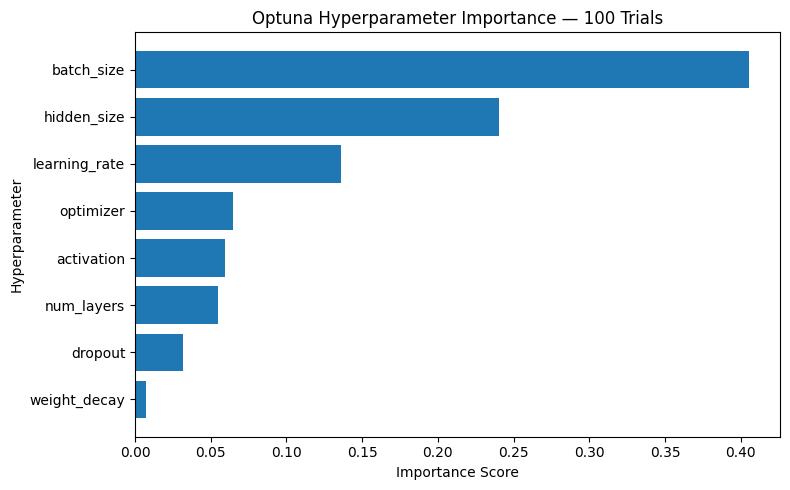

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Hyperparameter"][::-1],
    importance_df["Importance"][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Hyperparameter")
plt.title("Optuna Hyperparameter Importance — 100 Trials")

plt.tight_layout()
plt.show()

### 8.7 BiLSTM optimization results

This is the same presentation-aligned comparison used for the final BiLSTM optimization results.


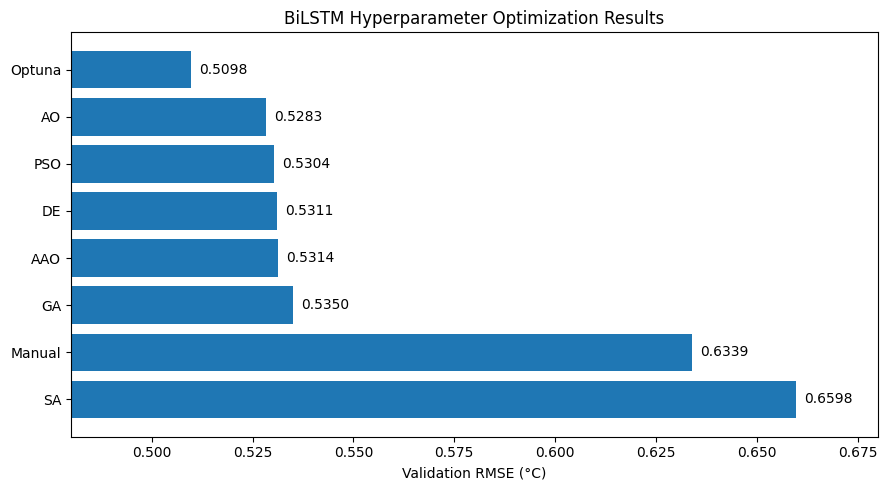

In [ ]:
import matplotlib.pyplot as plt

methods = [
    "Optuna", "AO", "PSO", "DE",
    "AAO", "GA", "Manual", "SA"
]

rmse = [
    0.5098, 0.5283, 0.5304, 0.5311,
    0.5314, 0.5350, 0.6339, 0.6598
]

plt.figure(figsize=(9, 5))

bars = plt.barh(methods, rmse)

plt.xlabel("Validation RMSE (°C)")
plt.title("BiLSTM Hyperparameter Optimization Results")

plt.xlim(0.48, 0.68)
plt.gca().invert_yaxis()

for bar, value in zip(bars, rmse):
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    "bilstm_optimization_updated.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Final selected BiLSTM hyperparameters
best_bilstm_params = study.best_params.copy()

print("Selected method: Optuna")
print("Total Optuna trials:", len(study.trials))
print("Best validation RMSE:", study.best_value)
print("Best BiLSTM hyperparameters:")
print(best_bilstm_params)


Selected method: Optuna
Total Optuna trials: 100
Best validation RMSE: 0.5097871388539711
Best BiLSTM hyperparameters:
{'hidden_size': 128, 'num_layers': 2, 'dropout': 0.030299515833055624, 'learning_rate': 0.0023493849794750388, 'batch_size': 128, 'weight_decay': 5.610732694133725e-05, 'optimizer': 'AdamW', 'activation': 'LeakyReLU'}


# Part C — TensorBoard HParams

TensorBoard is an experiment-tracking and visualization tool, not an optimization algorithm.

The dashboard used in the project was generated from the recorded BiLSTM experiments during the main search stage: Manual tuning, the initial Optuna run, and MEALPY candidate evaluations. The Optuna study was later extended to 100 total trials, and the best configuration did not change.


In [ ]:
# ============================================================
# Add all metaheuristic evaluations to HParams records
# ============================================================

bilstm_experiment_records.extend(meta_eval_records)

bilstm_experiments_df = pd.DataFrame(bilstm_experiment_records)

print("Recorded BiLSTM experiments:", len(bilstm_experiments_df))

display(
    bilstm_experiments_df
    .sort_values("Val_RMSE")
    .head(15)
)

In [ ]:
# ============================================================
# Prepare TensorBoard HParams records
# ============================================================

import tensorflow as tf
from tensorboard.plugins.hparams import api as hp

LOG_DIR = "logs/hparam_tuning"

!rm -rf logs/hparam_tuning

HP_METHOD = hp.HParam(
    "method",
    hp.Discrete(
        sorted(
            bilstm_experiments_df["Method"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
    )
)

HP_HIDDEN = hp.HParam(
    "hidden_size",
    hp.Discrete([32, 64, 96, 128])
)

HP_LAYERS = hp.HParam(
    "num_layers",
    hp.Discrete([1, 2])
)

HP_DROPOUT = hp.HParam(
    "dropout",
    hp.RealInterval(0.0, 0.4)
)

HP_LR = hp.HParam(
    "learning_rate",
    hp.RealInterval(2e-4, 3.2e-3)
)

HP_BATCH = hp.HParam(
    "batch_size",
    hp.Discrete([128, 256, 512])
)

HP_WEIGHT_DECAY = hp.HParam(
    "weight_decay",
    hp.RealInterval(1e-6, 1e-3)
)

HP_OPTIMIZER = hp.HParam(
    "optimizer",
    hp.Discrete(["Adam", "AdamW", "RMSprop"])
)

HP_ACTIVATION = hp.HParam(
    "activation",
    hp.Discrete(["ReLU", "LeakyReLU", "Tanh"])
)

METRIC_RMSE = "val_rmse"
METRIC_MAE = "val_mae"
METRIC_WITHIN1C = "within_1c_percent"

with tf.summary.create_file_writer(LOG_DIR).as_default():
    hp.hparams_config(
        hparams=[
            HP_METHOD,
            HP_HIDDEN,
            HP_LAYERS,
            HP_DROPOUT,
            HP_LR,
            HP_BATCH,
            HP_WEIGHT_DECAY,
            HP_OPTIMIZER,
            HP_ACTIVATION
        ],
        metrics=[
            hp.Metric(METRIC_RMSE, display_name="Validation RMSE"),
            hp.Metric(METRIC_MAE, display_name="Validation MAE"),
            hp.Metric(
                METRIC_WITHIN1C,
                display_name="Predictions Within ±1°C (%)"
            )
        ]
    )

print("HParams configuration created.")

In [ ]:
# ============================================================
# Write each experiment to TensorBoard
# ============================================================

tb_df = bilstm_experiments_df.dropna(
    subset=[
        "Method", "hidden_size", "num_layers", "dropout",
        "learning_rate", "batch_size", "weight_decay",
        "optimizer", "activation", "Val_RMSE"
    ]
).reset_index(drop=True)

for i, row in tb_df.iterrows():
    run_dir = f"{LOG_DIR}/run_{i:03d}"

    hparams = {
        HP_METHOD: str(row["Method"]),
        HP_HIDDEN: int(row["hidden_size"]),
        HP_LAYERS: int(row["num_layers"]),
        HP_DROPOUT: float(row["dropout"]),
        HP_LR: float(row["learning_rate"]),
        HP_BATCH: int(row["batch_size"]),
        HP_WEIGHT_DECAY: float(row["weight_decay"]),
        HP_OPTIMIZER: str(row["optimizer"]),
        HP_ACTIVATION: str(row["activation"])
    }

    with tf.summary.create_file_writer(run_dir).as_default():
        hp.hparams(hparams)

        tf.summary.scalar(
            METRIC_RMSE,
            float(row["Val_RMSE"]),
            step=1
        )

        mae_value = row.get("Val_MAE", np.nan)
        within_value = row.get("Within_1C_%", np.nan)

        if pd.notna(mae_value):
            tf.summary.scalar(
                METRIC_MAE,
                float(mae_value),
                step=1
            )

        if pd.notna(within_value):
            tf.summary.scalar(
                METRIC_WITHIN1C,
                float(within_value),
                step=1
            )

print("TensorBoard HParams logs written.")
print("Runs logged:", len(tb_df))

### Launch TensorBoard

In Colab, run the next cell and open **HParams → Parallel Coordinates**. Each line corresponds to one recorded BiLSTM configuration.


In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/hparam_tuning

# Part D — Final Fair Retraining and Test Evaluation

The baseline and optimized BiLSTM are retrained using the same final development split, maximum number of epochs, patience, and evaluation procedure. These are the final results reported in the presentation.


In [ ]:
# ============================================================
# Build combined train + validation sequences
# ============================================================

trainval_df = df_hourly.iloc[:val_end].copy()

trainval_X_raw = feature_scaler.transform(
    trainval_df[FEATURES]
).astype(np.float32)

trainval_y_raw = target_scaler.transform(
    trainval_df[[TARGET]]
).astype(np.float32).ravel()

X_trainval_seq, y_trainval_seq = make_sequences(
    trainval_X_raw,
    trainval_y_raw,
    SEQ_LEN,
    HORIZON
)

X_trainval_ml = X_trainval_seq.reshape(
    len(X_trainval_seq), -1
)

print("Train+Val DL:", X_trainval_seq.shape)
print("Train+Val ML:", X_trainval_ml.shape)

Train+Val DL: (59510, 24, 6)
Train+Val ML: (59510, 144)


### 10.1 Final optimized Random Forest


In [ ]:
# ============================================================
# Train final optimized Random Forest
# ============================================================

final_rf = RandomForestRegressor(
    **best_rf_params,
    n_jobs=-1,
    random_state=SEED
)

rf_final_train_start = time.perf_counter()
final_rf.fit(X_trainval_ml, y_trainval_seq)
rf_final_train_time = time.perf_counter() - rf_final_train_start

rf_final_pred_start = time.perf_counter()
rf_final_pred = final_rf.predict(X_test_ml)
rf_final_inference_time = time.perf_counter() - rf_final_pred_start

rf_final_metrics = regression_metrics(
    y_test_seq,
    rf_final_pred
)

print_metrics("Optimized Random Forest", rf_final_metrics)
print("Training time:", rf_final_train_time)
print("Inference time:", rf_final_inference_time)

Optimized Random Forest
  MAE: 0.3982
  RMSE: 0.5674
  R2: 0.9947
  Within_1C_%: 92.5594
Training time: 588.398702036
Inference time: 0.24049529299918504


### 10.2 Fair baseline vs optimized BiLSTM retraining

Both configurations use the same chronological final training/internal-validation split, **20 maximum epochs**, and **patience = 3**.


In [ ]:
# Same final development split for both models
internal_cut = int(len(X_trainval_seq) * 0.90)

X_final_train = X_trainval_seq[:internal_cut]
y_final_train = y_trainval_seq[:internal_cut]

X_final_val = X_trainval_seq[internal_cut:]
y_final_val = y_trainval_seq[internal_cut:]


# Original Phase 4 BiLSTM configuration
baseline_cfg = {
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "learning_rate": 1e-3,
    "batch_size": 256,
    "weight_decay": 0.0,
    "optimizer": "Adam",
    "activation": "ReLU"
}


# ---------- Retrain baseline ----------
baseline_final_model, _, baseline_train_time, _ = train_bilstm_config(
    baseline_cfg,
    X_final_train, y_final_train,
    X_final_val, y_final_val,
    epochs=20,
    patience=3,
    verbose=True
)


# ---------- Retrain optimized ----------
optimized_final_model, _, optimized_train_time, _ = train_bilstm_config(
    best_bilstm_params,
    X_final_train, y_final_train,
    X_final_val, y_final_val,
    epochs=20,
    patience=3,
    verbose=True
)

Epoch 01 | Val RMSE: 0.9813 °C
Epoch 02 | Val RMSE: 0.7171 °C
Epoch 03 | Val RMSE: 0.6870 °C
Epoch 04 | Val RMSE: 0.6839 °C
Epoch 05 | Val RMSE: 0.6817 °C
Epoch 06 | Val RMSE: 0.6883 °C
Epoch 07 | Val RMSE: 0.6680 °C
Epoch 08 | Val RMSE: 0.6897 °C
Epoch 09 | Val RMSE: 0.6693 °C
Epoch 10 | Val RMSE: 0.6868 °C
Epoch 01 | Val RMSE: 0.6893 °C
Epoch 02 | Val RMSE: 0.6721 °C
Epoch 03 | Val RMSE: 0.6707 °C
Epoch 04 | Val RMSE: 0.7046 °C
Epoch 05 | Val RMSE: 0.6744 °C
Epoch 06 | Val RMSE: 0.6615 °C
Epoch 07 | Val RMSE: 0.6726 °C
Epoch 08 | Val RMSE: 0.6655 °C
Epoch 09 | Val RMSE: 0.6790 °C


In [ ]:
# ============================================
# FINAL TEST EVALUATION — BASELINE vs OPTIMIZED
# ============================================

baseline_test_loader = make_loader(
    X_test_seq,
    y_test_seq,
    batch_size=baseline_cfg["batch_size"],
    shuffle=False
)

optimized_test_loader = make_loader(
    X_test_seq,
    y_test_seq,
    batch_size=best_bilstm_params["batch_size"],
    shuffle=False
)


# Baseline
y_base_true, y_base_pred, _ = evaluate_dl_scaled(
    baseline_final_model,
    baseline_test_loader
)

baseline_test_metrics = regression_metrics(
    y_base_true,
    y_base_pred
)


# Optimized
y_opt_true, y_opt_pred, _ = evaluate_dl_scaled(
    optimized_final_model,
    optimized_test_loader
)

optimized_test_metrics = regression_metrics(
    y_opt_true,
    y_opt_pred
)


print("BASELINE BiLSTM")
print_metrics("Baseline BiLSTM", baseline_test_metrics)

print("\nOPTIMIZED BiLSTM")
print_metrics("Optimized BiLSTM", optimized_test_metrics)


rmse_improvement = (
    (baseline_test_metrics["RMSE"] - optimized_test_metrics["RMSE"])
    / baseline_test_metrics["RMSE"]
    * 100
)

print(
    f"\nRMSE improvement after optimization: "
    f"{rmse_improvement:.2f}%"
)

BASELINE BiLSTM
Baseline BiLSTM
  MAE: 0.3875
  RMSE: 0.5559
  R2: 0.9949
  Within_1C_%: 93.0363

OPTIMIZED BiLSTM
Optimized BiLSTM
  MAE: 0.3832
  RMSE: 0.5549
  R2: 0.9949
  Within_1C_%: 93.1699

RMSE improvement after optimization: 0.18%


### 10.3 Final test RMSE comparison

The optimized BiLSTM achieved the lowest final test RMSE. Its RMSE improvement over the fairly retrained baseline is approximately **0.18%**.


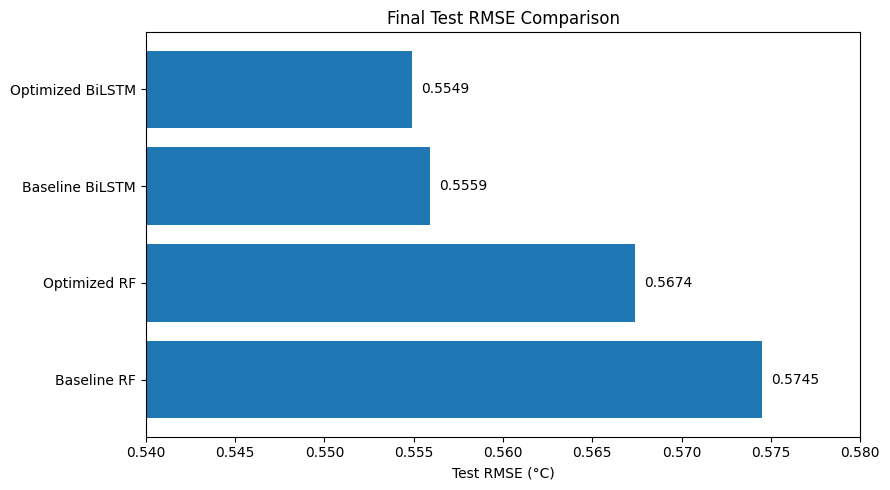

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Optimized BiLSTM",
    "Baseline BiLSTM",
    "Optimized RF",
    "Baseline RF"
]

rmse = [
    0.5549,
    0.5559,
    0.5674,
    0.5745
]

plt.figure(figsize=(9, 5))

bars = plt.barh(models, rmse)

plt.xlabel("Test RMSE (°C)")
plt.title("Final Test RMSE Comparison")

plt.xlim(0.54, 0.58)
plt.gca().invert_yaxis()

for bar, value in zip(bars, rmse):
    plt.text(
        value + 0.0005,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    "final_test_rmse_updated.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 11. Final presentation-aligned results


In [ ]:
final_results = pd.DataFrame([
    {"Model": "Optimized BiLSTM", "RMSE": optimized_test_metrics["RMSE"], "MAE": optimized_test_metrics["MAE"], "R2": optimized_test_metrics["R2"], "Within_1C_%": optimized_test_metrics["Within_1C_%"]},
    {"Model": "Retrained Baseline BiLSTM", "RMSE": baseline_test_metrics["RMSE"], "MAE": baseline_test_metrics["MAE"], "R2": baseline_test_metrics["R2"], "Within_1C_%": baseline_test_metrics["Within_1C_%"]},
    {"Model": "Optimized Random Forest", "RMSE": rf_final_metrics["RMSE"], "MAE": rf_final_metrics["MAE"], "R2": rf_final_metrics["R2"], "Within_1C_%": rf_final_metrics["Within_1C_%"]},
    {"Model": "Random Forest Baseline", "RMSE": rf_baseline_metrics["RMSE"], "MAE": rf_baseline_metrics["MAE"], "R2": rf_baseline_metrics["R2"], "Within_1C_%": rf_baseline_metrics["Within_1C_%"]}
]).sort_values("RMSE").reset_index(drop=True)

display(final_results.style.format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}", "Within_1C_%": "{:.2f}%"
}))

print(f"Random Forest RMSE improvement: {(rf_baseline_metrics['RMSE'] - rf_final_metrics['RMSE']) / rf_baseline_metrics['RMSE'] * 100:.2f}%")
print(f"BiLSTM RMSE improvement: {rmse_improvement:.2f}%")
print("Final selected model: Optimized BiLSTM")


                    Model   RMSE    MAE     R2  Within_1C_%
         Optimized BiLSTM 0.5549 0.3832 0.9949        93.17
Retrained Baseline BiLSTM 0.5559 0.3875 0.9949        93.04
  Optimized Random Forest 0.5674 0.3982 0.9947        92.56
   Random Forest Baseline 0.5745 0.4031 0.9946        92.17

Random Forest RMSE improvement: 1.24%
BiLSTM RMSE improvement: 0.18%
Final selected model: Optimized BiLSTM


## 12. Save final outputs

Only the final presentation-aligned artifacts are saved here.


In [ ]:
OUTPUT_DIR = "phase5_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

rf_search_summary.to_csv(f"{OUTPUT_DIR}/rf_optimization_summary.csv", index=False)
importance_df.to_csv(f"{OUTPUT_DIR}/optuna_parameter_importance_100_trials.csv", index=False)
final_results.to_csv(f"{OUTPUT_DIR}/final_model_comparison.csv", index=False)

joblib.dump(final_rf, f"{OUTPUT_DIR}/optimized_random_forest.joblib")

torch.save(
    {
        "best_params": best_bilstm_params,
        "state_dict": optimized_final_model.state_dict(),
        "features": FEATURES,
        "seq_len": SEQ_LEN,
        "horizon": HORIZON,
        "baseline_test_metrics": baseline_test_metrics,
        "optimized_test_metrics": optimized_test_metrics,
        "rmse_improvement_percent": rmse_improvement
    },
    f"{OUTPUT_DIR}/optimized_bilstm.pt"
)

with open(f"{OUTPUT_DIR}/best_hyperparameters.json", "w") as f:
    json.dump(
        {
            "best_rf_method": best_rf_method,
            "best_rf_params": best_rf_params,
            "best_bilstm_method": "Optuna",
            "optuna_total_trials": len(study.trials),
            "best_bilstm_params": best_bilstm_params
        },
        f,
        indent=2,
        default=str
    )

print("Final Phase 5 outputs saved to:", OUTPUT_DIR)


Final Phase 5 outputs saved to: phase5_outputs


## 13. Conclusion

- Random Forest was the strongest baseline ML model; BiLSTM was the strongest baseline DL model and strongest overall baseline.
- RandomizedSearchCV produced the best Random Forest tuning result.
- Optuna produced the best BiLSTM validation RMSE: **0.5098°C**.
- Optuna was extended to **100 total trials**; the additional trials did not improve the best result.
- Random Forest test RMSE improved from **0.5745°C to 0.5674°C** (**1.24%**).
- Under identical final retraining conditions, BiLSTM test RMSE improved from **0.5559°C to 0.5549°C** (**0.18%**).
- **Final selected model: Optimized BiLSTM.**
